In [1]:
import numpy as np
import matplotlib as mpl
#mpl.use('pdf')
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

# plt.rc('font', family='serif', serif='Times')
# Arial
plt.rc('font', family='serif', serif='Times')
plt.rc('text', usetex=True)
plt.rc('xtick', labelsize=7)
plt.rc('ytick', labelsize=7)
plt.rc('axes', labelsize=8)
#axes.linewidth : 0.5
plt.rc('axes', linewidth=0.5)
#ytick.major.width : 0.5
plt.rc('ytick.major', width=0.5)
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rc('ytick.minor', visible=True)

# set grid under the plot
# https://stackoverflow.com/questions/23357798/how-to-draw-grid-lines-behind-matplotlib-bar-graph
# https://stackoverflow.com/questions/1726391/matplotlib-draw-grid-lines-behind-other-graph-elements/39039520#39039520
plt.rc('axes', axisbelow=True)

#plt.style.use(r"..\..\styles\infocom.mplstyle") # Insert your save location here
# plt.style.use('ggplot')

# width as measured in inkscape
fig_width = 3.487
fig_height = fig_width / 1.618
# fig_height = 1.8
#fig_height = fig_width / 1.3 / 2

In [2]:
import numpy as np
num_instances = 4
# file_list = list(range(num_cases))
# filename_prefix = "results/results_japan_averaged_rate"
# folder_prefix = "results/TS8Module10-0716-8Ins/"
# folder_prefix = "results/TS8Module10-0718-1Ins/"
folder_prefix = "results/usnet-8ins-new/"
acceptance_ratio = np.zeros((4, num_instances), dtype=float)
stored_keys = np.zeros((4, num_instances), dtype=float)
num_physical_hops = np.zeros((4, num_instances), dtype=float)
num_virtual_hops = np.zeros((4, num_instances), float)
num_qkd_module = np.zeros((4, num_instances), dtype=float)

case_prefix_list = ["results_qkp_No_OB_TR_usnet_averaged_rate", "results_qkp_OB_usnet_averaged_rate", 
         "results_qkp_TR_usnet_averaged_rate", "results_qkp_OB_TR_usnet_averaged_rate"]

In [3]:
average_key_rate_index = 4
for j in range(num_instances):
    #for file in file_list:
#     file = file_list[j]
    for i in range(len(case_prefix_list)):
        case_prefix = case_prefix_list[i]
        filename = folder_prefix + case_prefix + str(average_key_rate_index) + "_1.txt"
        with open(filename, "r") as f:
            lines = f.readlines()
            tmp = 100 * float(lines[0+2*j].split(" ")[0])
            acceptance_ratio[i][j] = tmp
            stored_keys[i][j] = float(lines[1+2*j].split(" ")[0])
            num_qkd_module[i][j] = float(lines[1+2*j].split(" ")[1])
            num_physical_hops[i][j] = float(lines[1+2*j].split(" ")[2])
            num_virtual_hops[i][j] = float(lines[1+2*j].split(" ")[3])
            
print(acceptance_ratio)
print(num_qkd_module)

[[15.51136364 15.51136364 15.51136364 15.51136364]
 [43.92045455 49.54545455 55.         65.625     ]
 [44.88636364 57.27272727 74.48863636 93.52272727]
 [50.96590909 65.56818182 82.84090909 97.72727273]]
[[2.         1.6        1.5        1.33333333]
 [2.         1.68167719 1.6193795  1.47637836]
 [3.68942044 3.110689   3.05333587 2.8673982 ]
 [2.79134052 2.35349769 2.28562236 2.3714022 ]]


In [4]:
dataMatrix = acceptance_ratio
print(dataMatrix)

[[15.51136364 15.51136364 15.51136364 15.51136364]
 [43.92045455 49.54545455 55.         65.625     ]
 [44.88636364 57.27272727 74.48863636 93.52272727]
 [50.96590909 65.56818182 82.84090909 97.72727273]]


[0 1 2 3]
['0', '3', '6', '9']


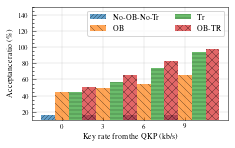

In [5]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances-1)


# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12', '15']
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = ['3', '6', '9', '12', '15', '18']

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Acceptance ratio (\%)')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(10, 150)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.17, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-acceptance-ratio.pdf')
fig.savefig('plot/qkp-acceptance-ratio.png')

In [6]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[2.         1.6        1.5        1.33333333]
 [2.         1.68167719 1.6193795  1.47637836]
 [3.68942044 3.110689   3.05333587 2.8673982 ]
 [2.79134052 2.35349769 2.28562236 2.3714022 ]]


In [7]:
dataMatrix = stored_keys
print(dataMatrix)

[[ 2198.875       2201.75        2204.625       2207.5       ]
 [ 1018.01769431   759.5068645    503.50505115   205.85146185]
 [  330.234375    -588.796875   -1445.796875   -2055.078125  ]
 [  327.6880413   -560.38930057 -1392.48994537 -1926.4640818 ]]


[0 1 2 3]
['0', '3', '6', '9']


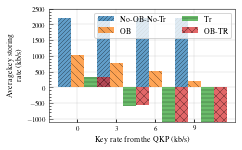

In [8]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances-1)


# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12', '15']
x_tick_label_list = x_tick_label_list[0:num_instances]

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average key storing \n rate (kb/s)')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(-1100, 2500)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.21, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-key-storing-rate.pdf')
fig.savefig('plot/qkp-key-storing-rate.png')

In [9]:
dataMatrix = num_qkd_module
print(dataMatrix)

[[2.         1.6        1.5        1.33333333]
 [2.         1.68167719 1.6193795  1.47637836]
 [3.68942044 3.110689   3.05333587 2.8673982 ]
 [2.79134052 2.35349769 2.28562236 2.3714022 ]]


[0 1 2 3]
['0', '3', '6', '9']


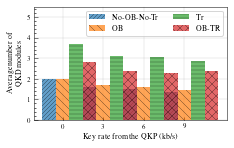

In [10]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances-1)


# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12', '15']
x_tick_label_list = x_tick_label_list[0:num_instances]


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n QKD modules')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(0, 5.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-num-qkd-modules.pdf')
fig.savefig('plot/qkp-num-qkd-modules.png')

In [11]:
dataMatrix = num_physical_hops
print(dataMatrix)

[[1.         0.8        0.75       0.66666667]
 [1.         0.84083859 0.80968975 0.73818918]
 [1.78724154 1.45934798 1.41061489 1.29734174]
 [1.33033841 1.10841475 1.05381669 1.08615408]]


[0 1 2 3]
['0', '3', '6', '9']


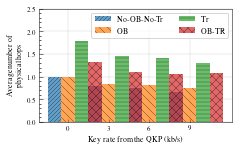

In [12]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances-1)


# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12', '15']
x_tick_label_list = x_tick_label_list[0:num_instances]

# x_tick_label_list = ['J1', 'J2', 'J3', 'G1', 'G2', 'G3']


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n physical hops')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(0, 2.5)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-num-physical-hops.pdf')
fig.savefig('plot/qkp-num-physical-hops.png')

In [13]:
dataMatrix = num_virtual_hops
print(dataMatrix)

[[0.         0.2        0.25       0.33333333]
 [0.         0.15916141 0.19031025 0.26181082]
 [0.1147875  0.59576035 0.82887372 1.03231422]
 [0.15634442 0.52674008 0.71808866 0.78314975]]


[0 1 2 3]
['0', '3', '6', '9']


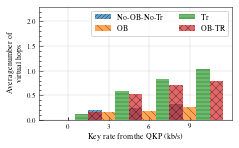

In [14]:
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances-1)


# fig, ax = plt.subplots(nrows=1, ncols=2)
# ax1 = ax[0,0]
# ax2 = ax[0,1]
fig, (ax1) = plt.subplots(1, 1)


#ax1.bar(x, objective)
#ax1.bar(x, objective[0])
# x_tick_label_list = ['J-TS1', 'J-TS2', 'J-TS3', 'G-TS1', 'G-TS2', 'G-TS3']
x_tick_label_list = ['0', '3', '6', '9', '12', '15']
x_tick_label_list = x_tick_label_list[0:num_instances]


label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']

patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

plt.rcParams['hatch.linewidth'] = 0.25  # previous pdf hatch linewidth
#plt.rcParams['hatch.linewidth'] = 1.0  # previous svg hatch linewidth
#plt.rcParams['hatch.color'] = 'r'

for i in range(4):
    ax1.bar(ind + width * (i-1), dataMatrix[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
#                tick_label=x_tick_label_list)
               #yerr=error[i], ecolor='black', capsize=1)


label_position = ind #+ width * (1.5 - 1)
print(label_position)
print(x_tick_label_list)

ax1.set_xticks(label_position)
ax1.set_xticklabels(x_tick_label_list)
# ax1.set_xticks(label_position, x_tick_label_list)

# ax1.set_xticklabels(x_tick_label_list)

ax1.set_ylabel('Average number of \n virtual hops')
ax1.set_xlabel('Key rate from the QKP (kb/s)')
ax1.set_ylim(0, 2.3)

#ax1.xaxis.set_label_coords(0.5,-0.17)
#ax1.yaxis.set_label_coords(-0.17,0.5)



ax1.legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
          ncol=2, prop={'size': 8})
#ax1.legend(loc='best')
fig.set_size_inches(fig_width, fig_height)
#mpl.pyplot.subplots_adjust(wspace = 0.3)

fig.subplots_adjust(left=.18, bottom=.22, right=.95, top=.95)
#ax1.grid(color='b', ls = '-.', lw = 0.25)
ax1.grid(lw = 0.25, clip_on=False)


plt.show()
fig.savefig('plot/qkp-num-virtual-hops.pdf')
fig.savefig('plot/qkp-num-virtual-hops.png')

[0 1 2 3 4 5 6]
[<AxesSubplot:> <AxesSubplot:> <AxesSubplot:> <AxesSubplot:>]
[0.1, 1.1, 2.1, 3.1]
['0', '90', '180', '270']


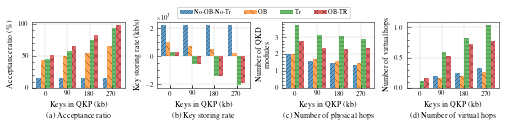

In [15]:
fig, ax = plt.subplots(nrows=1, ncols=4)
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances+1)

stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']
patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

x_tick_label_list = ['0', '3', '6', '9', '12', '15']
x_tick_label_list = [int(elem) * 30 for elem in x_tick_label_list]
x_tick_label_list = [str(elem) for elem in x_tick_label_list]
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = [float(elem) for elem in x_tick_label_list]

dataMatrix0 = acceptance_ratio
for i in range(4):
    ax[0].bar(ind + width * (i-1), dataMatrix0[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)

dataMatrix1 = stored_keys
for i in range(4):
    ax[1].bar(ind + width * (i-1), dataMatrix1[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)

dataMatrix2 = num_qkd_module
for i in range(4):
    ax[2].bar(ind + width * (i-1), dataMatrix2[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)
    

dataMatrix3 = num_virtual_hops
for i in range(4):
    ax[3].bar(ind + width * (i-1), dataMatrix3[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.7)

ax[0].set_ylabel('Acceptance ratio (\%)')
ax[0].set_xlabel('Keys in QKP (kb)')
# ax[0].set_title("subtitle")
ax[0].set_title('(a) Acceptance ratio', y=-0.55, fontsize=8)

ax[1].set_ylabel('Key storing rate (kb/s)')
ax[1].set_xlabel('Keys in QKP (kb)')
ax[1].set_title('(b) Key storing rate', y=-0.55, fontsize=8)

ax[2].set_ylabel('Number of QKD \n modules')
ax[2].set_xlabel('Keys in QKP (kb)')
ax[2].set_title('(c) Number of physical hops', y=-0.55, fontsize=8)

ax[3].set_ylabel('Number of virtual hops')
ax[3].set_xlabel('Keys in QKP (kb)')
ax[3].set_title('(d) Number of virtual hops', y=-0.55, fontsize=8)

# for i in range(0, 4):
#     ax[i].legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
#               ncol=1, prop={'size': 5}, labelspacing=0.2)
# ax[0].legend(loc='upper center', bbox_to_anchor=(2.3, 1.28),
#           ncol=5, prop={'size': 6.5}, handletextpad=0.2)
ax[0].legend(loc='upper center', bbox_to_anchor=(2.5, 1.28),
          ncol=5, prop={'size': 6.5}, handletextpad=0.2)
    
mpl.pyplot.subplots_adjust(wspace = 0.35, hspace=0.5)
fig.subplots_adjust(left=.06, bottom=.3, right=.99, top=.85)

label_position = ind #+ width * (1.5 - 1)
label_position = [elem + width/2 for elem in label_position]
print(label_position)
print(x_tick_label_list)

for i in range(0, 4):
    ax[i].grid(lw = 0.25)
    ax[i].set_xticks(label_position)
    ax[i].set_xticklabels(x_tick_label_list)
ax[1].ticklabel_format(style='sci', scilimits=(-1,2), axis='y')

#     ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))

# ax[1].set_ylim(-995, 1500)


fig.set_size_inches(fig_width*2, fig_height/1.3)
plt.show()
fig.savefig('plot/@module-allfigs.png')
fig.savefig('plot/@qkp-allfigs.pdf')
# fig.savefig('heuristic-utilization-CC.pdf')

[0 1 2 3 4 5 6]
[<AxesSubplot:> <AxesSubplot:> <AxesSubplot:> <AxesSubplot:>]
[0.1, 1.1, 2.1, 3.1]
['0', '90', '180', '270']


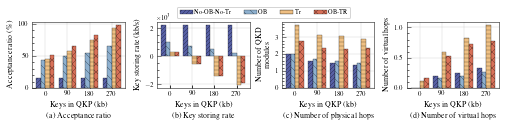

In [16]:
color_list = ['#4676b1', '#e98229', '#559f36', '#d76960']
color_list = ['#809dcc', '#eca054', '#7fbf62', '#d76960']
color_list = ['#809dcc', '#eca054', '#7fbf62', '#d76960']
color_list = ['#346067', '#5095a1', '#fcf4f2', '#efb6b0']
color_list = ['#46509d', '#82a8ca', '#eeb976', '#d46247']

fig, ax = plt.subplots(nrows=1, ncols=4)
N = num_instances
ind = np.arange(N) 
width = 1 / (num_instances+1)

stage = np.arange(7)

print(stage)
print(ax)
marker_list = ["p", "v", "x", ".", "*"]
#label_list = ['No-rec', 'Link-rec', 'Lim-rec(5,0)', 'Lim-rec(5,2)', 'Any-rec']
label_list = ['No-OB-No-Tr', 'OB', 'Tr', 'OB-TR', 'Any-rec']
patterns = ('//////','\\\\\\','---',  'xxx', 'ooo ', '\\', '\\\\','++', '*', 'O', '.')

x_tick_label_list = ['0', '3', '6', '9', '12', '15']
x_tick_label_list = [int(elem) * 30 for elem in x_tick_label_list]
x_tick_label_list = [str(elem) for elem in x_tick_label_list]
x_tick_label_list = x_tick_label_list[0:num_instances]
# x_tick_label_list = [float(elem) for elem in x_tick_label_list]

dataMatrix0 = acceptance_ratio
for i in range(4):
    ax[0].bar(ind + width * (i-1), dataMatrix0[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.9, color=color_list[i], edgecolor='black', linewidth=0.3)

dataMatrix1 = stored_keys
for i in range(4):
    ax[1].bar(ind + width * (i-1), dataMatrix1[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.9, color=color_list[i], edgecolor='black', linewidth=0.3)

dataMatrix2 = num_qkd_module
for i in range(4):
    ax[2].bar(ind + width * (i-1), dataMatrix2[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.9, color=color_list[i], edgecolor='black', linewidth=0.3)
    

dataMatrix3 = num_virtual_hops
for i in range(4):
    ax[3].bar(ind + width * (i-1), dataMatrix3[i], width, label=label_list[i],
               hatch=patterns[i], alpha=0.9, color=color_list[i], edgecolor='black', linewidth=0.3)

ax[0].set_ylabel('Acceptance ratio (\%)')
ax[0].set_xlabel('Keys in QKP (kb)')
# ax[0].set_title("subtitle")
ax[0].set_title('(a) Acceptance ratio', y=-0.55, fontsize=8)

ax[1].set_ylabel('Key storing rate (kb/s)')
ax[1].set_xlabel('Keys in QKP (kb)')
ax[1].set_title('(b) Key storing rate', y=-0.55, fontsize=8)

ax[2].set_ylabel('Number of QKD \n modules')
ax[2].set_xlabel('Keys in QKP (kb)')
ax[2].set_title('(c) Number of physical hops', y=-0.55, fontsize=8)

ax[3].set_ylabel('Number of virtual hops')
ax[3].set_xlabel('Keys in QKP (kb)')
ax[3].set_title('(d) Number of virtual hops', y=-0.55, fontsize=8)

# for i in range(0, 4):
#     ax[i].legend(loc='upper right',# bbox_to_anchor=(0.5, 1.2),
#               ncol=1, prop={'size': 5}, labelspacing=0.2)
# ax[0].legend(loc='upper center', bbox_to_anchor=(2.3, 1.28),
#           ncol=5, prop={'size': 6.5}, handletextpad=0.2)
ax[0].legend(loc='upper center', bbox_to_anchor=(2.5, 1.28),
          ncol=5, prop={'size': 6.5}, handletextpad=0.2)
    
mpl.pyplot.subplots_adjust(wspace = 0.35, hspace=0.5)
fig.subplots_adjust(left=.06, bottom=.3, right=.99, top=.85)

label_position = ind #+ width * (1.5 - 1)
label_position = [elem + width/2 for elem in label_position]
print(label_position)
print(x_tick_label_list)

for i in range(0, 4):
    ax[i].grid(lw = 0.25)
    ax[i].set_xticks(label_position)
    ax[i].set_xticklabels(x_tick_label_list)

ax[1].ticklabel_format(style='sci', scilimits=(-1,2), axis='y')

#     ax[i].xaxis.set_major_locator(MaxNLocator(integer=True))

# ax[1].set_ylim(-995, 1500)


fig.set_size_inches(fig_width*2, fig_height/1.3)
plt.show()
fig.savefig('plot/@module-allfigs.png')
fig.savefig('plot/@qkp-allfigs.pdf')
# fig.savefig('heuristic-utilization-CC.pdf')